In [55]:
# read with pandas

import pandas as pd


cols = ["[RP2006]", "F[OIII]", "e_F[OIII]", "_RA", "_DE"]
tablea1 = pd.read_csv("tablea1.csv", sep=",")
tablea2 = pd.read_csv("tablea2.csv", sep=",")

tablea2.columns
coords = pd.concat([tablea1[cols], tablea2[cols]], ignore_index=False)

coords

,[RP2006],F[OIII],e_F[OIII],_RA,_DE
0,10,2.020000e-13,1.000000e-14,85.63829,-70.49003
1,12,2.310000e-13,1.100000e-14,86.14458,-70.36133
2,74,3.780000e-14,3.200000e-14,84.51925,-70.49053
3,75,4.610000e-14,2.500000e-14,86.60537,-71.38953
4,106,4.120000e-15,3.500000e-15,85.15667,-70.46528
...,...,...,...,...,...
408,1956,4.440000e-14,2.220000e-15,86.66408,-70.94725
409,1957,1.340000e-14,6.680000e-16,87.51804,-70.67650
410,1958,1.170000e-15,9.930000e-16,85.91162,-70.56714
411,1962,2.000000e-14,1.000000e-15,84.56867,-70.70089


In [ ]:
from astropy.coordinates import SkyCoord
import astropy.units as u

snr = SkyCoord("05h47m50s", "-70d24m45s", frame="icrs")
pnes = SkyCoord(coords["_RA"].values * u.deg, coords["_DE"].values * u.deg, frame="icrs")

pnes

<SkyCoord (ICRS): (ra, dec) in deg
    [(85.63829, -70.49003), (86.14458, -70.36133), (84.51925, -70.49053),
     (86.60537, -71.38953), (85.15667, -70.46528), (85.65265, -70.15891),
     (85.67121, -70.09697), (84.81029, -70.00517), (84.724  , -69.96536),
     (87.41146, -69.16647), (86.77   , -69.45892), (85.40254, -69.45272),
     (85.601  , -69.88475), (84.57312, -68.97961), (85.34187, -68.12894),
     (86.27487, -68.11414), (85.56421, -68.81547), (85.94829, -68.64308),
     (86.60587, -67.83411), (85.18579, -67.30214), (84.08671, -67.30208),
     (85.12832, -66.29373), (85.08392, -67.03383), (84.81396, -66.82878),
     (84.97825, -66.57017), (80.67073, -71.31855), (81.11396, -70.37325),
     (81.06537, -70.89897), (81.22948, -71.54896), (81.93242, -71.43236),
     (82.26187, -70.32356), (82.63824, -70.74374), (82.69112, -70.83789),
     (82.84122, -70.6793 ), (83.66229, -70.33208), (82.38625, -70.29417),
     (82.60946, -71.23   ), (83.62571, -70.47625), (82.14337, -70.55044),
   

In [71]:
sep = snr.separation(pnes)

fov = coords[sep < 10 * u.arcmin]

fov

,[RP2006],F[OIII],e_F[OIII],_RA,_DE
21,99,4.260000e-14,2.130000e-15,86.59979,-70.43217
22,102,7.000000e-15,3.500000e-16,87.33442,-70.46939
23,103,2.060000e-14,1.030000e-15,86.75637,-70.47847
27,122,4.290000e-15,2.150000e-16,86.86958,-70.33775


/Users/markpirgalin/anaconda3/lib/python3.11/site-packages/astropy/wcs/wcs.py:805: FITSFixedWarning: 'datfix' made the change 'Set DATE-OBS to '2020-11-12T03:31:35.772' from MJD-OBS'.
  warnings.warn(


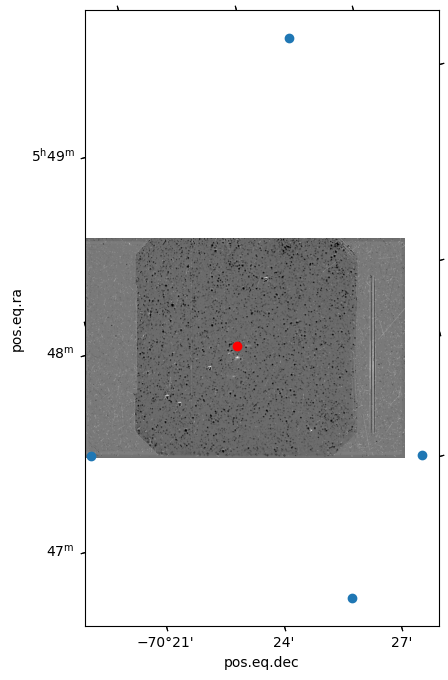

In [ ]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np

image = fits.open("test_sub3.fits")[0].data
wcs_hdul = fits.open("images/SNR_OIII.fits")

wcs = WCS(wcs_hdul["SCI"].header)

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs)

ax.imshow(image, origin="lower", cmap="gray", vmin=np.percentile(image,1), vmax=np.percentile(image,99.5))

ax.scatter(fov["_RA"].values *u.deg, fov["_DE"].values *u.deg, transform=ax.get_transform("world"))

ax.scatter(snr.ra, snr.dec, color="r", transform=ax.get_transform("world"))

/Users/markpirgalin/anaconda3/lib/python3.11/site-packages/astropy/wcs/wcs.py:805: FITSFixedWarning: 'datfix' made the change 'Set DATE-OBS to '2020-11-12T03:31:35.772' from MJD-OBS'.
  warnings.warn(


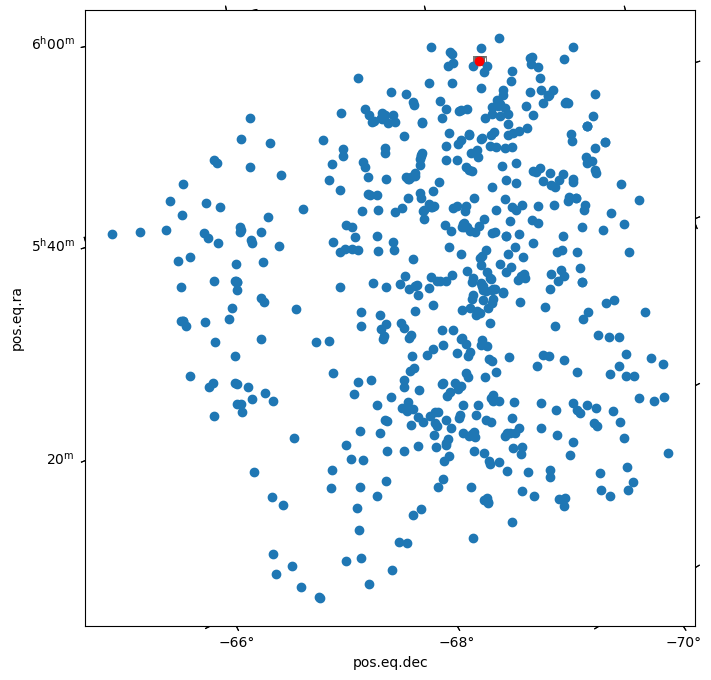

In [ ]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np

image = fits.open("test_sub3.fits")[0].data
wcs_hdul = fits.open("images/SNR_OIII.fits")

wcs = WCS(wcs_hdul["SCI"].header)

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs)

fov = coords

ax.imshow(image, origin="lower", cmap="gray", vmin=np.percentile(image,1), vmax=np.percentile(image,99.5))

ax.scatter(fov["_RA"].values *u.deg, fov["_DE"].values *u.deg, transform=ax.get_transform("world"))

ax.scatter(snr.ra, snr.dec, color="r", transform=ax.get_transform("world"))

In [105]:
# read with pandas

import pandas as pd


# cols = ["[RP2006]", "F[OIII]", "e_F[OIII]", "_RA", "_DE"]
table = pd.read_csv("reid.csv", sep=",")

# table = table.rename(columns={
#     "RAJ2000": "_RA",
#     "DEJ2000": "_DE"
# })

table

,Name,Umag,Bmag,n_Bmag,Vmag,Imag,Jmag,n_Jmag,Hmag,n_Hmag,...,n_[4_5],[5_8],n_[5_8],[8_0],n_[8_0],[24],n_[24],SimbadName,_RA,_DE
0,MG 74,NaN,NaN,,NaN,NaN,17.666,*,NaN,,...,,NaN,,NaN,,NaN,,MGPN LMC74,85.22875,-74.68833
1,SMP 79,NaN,NaN,,NaN,NaN,15.888,,15.518,,...,,NaN,,NaN,,NaN,,SMP LMC 79,83.53604,-74.33531
2,SMP 81,NaN,NaN,,NaN,NaN,15.990,*,16.032,,...,,NaN,,NaN,,NaN,,SMP LMC 81,83.83683,-73.92508
3,RP4673,NaN,NaN,,NaN,NaN,NaN,,NaN,,...,,NaN,,NaN,,NaN,,[RP2006] 4673,82.42904,-72.91558
4,MG 61,NaN,NaN,,NaN,NaN,NaN,,NaN,,...,,NaN,,13.890,,8.755,,MGPN LMC61,83.30583,-72.61306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,RP3876,NaN,21.174,,20.523,20.341,NaN,,NaN,,...,,NaN,,NaN,,NaN,,[RP2006] 3876,NaN,NaN
601,RP3886,NaN,20.314,,19.974,19.543,19.240,,NaN,,...,,NaN,,NaN,,NaN,,[RP2006] 3886,NaN,NaN
602,RP3923,NaN,23.024,,22.138,NaN,NaN,,NaN,,...,,NaN,,NaN,,NaN,,[RP2006] 3923,NaN,NaN
603,RP4388,NaN,20.795,,20.176,NaN,18.490,,18.120,,...,,14.416,,12.926,,NaN,,[RP2006] 4388,NaN,NaN


In [108]:
pnes = SkyCoord(table["_RA"].values * u.deg, table["_DE"].values * u.deg, frame="icrs")
sep = snr.separation(pnes)

fov = table[sep < 10 * u.arcmin]

fov

,Name,Umag,Bmag,n_Bmag,Vmag,Imag,Jmag,n_Jmag,Hmag,n_Hmag,...,n_[4_5],[5_8],n_[5_8],[8_0],n_[8_0],[24],n_[24],SimbadName,_RA,_DE
159,RP103,19.725,19.995,,19.914,19.620,18.900,,NaN,,...,,NaN,,NaN,,NaN,,[RP2006] 103,86.75637,-70.47847
160,RP102,19.418,19.112,,18.113,17.116,16.395,*,15.508,,...,,15.17,,NaN,,NaN,,[RP2006] 102,87.33442,-70.46939
161,RP122,19.276,19.462,,19.245,18.738,17.140,,17.020,,...,,NaN,,NaN,,NaN,,[RP2006] 122,86.86958,-70.33775
191,RP99,19.979,19.639,,18.594,17.799,17.190,*,16.790,,...,,NaN,,NaN,,NaN,,[RP2006] 99,86.59979,-70.43217


/Users/markpirgalin/anaconda3/lib/python3.11/site-packages/astropy/wcs/wcs.py:805: FITSFixedWarning: 'datfix' made the change 'Set DATE-OBS to '2020-11-12T03:31:35.772' from MJD-OBS'.
  warnings.warn(


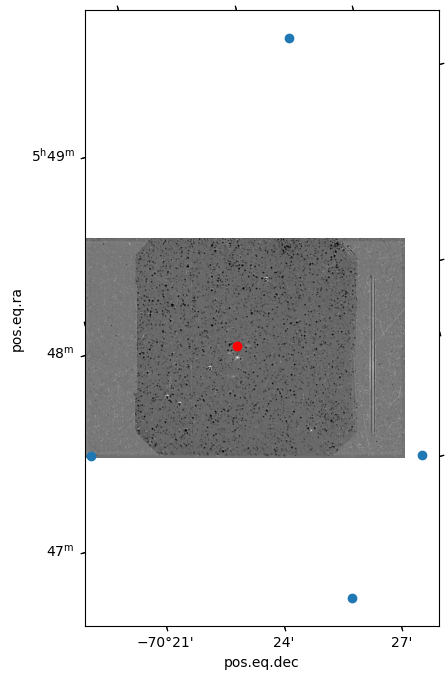

In [109]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np

image = fits.open("images/csi.fits")[0].data
wcs_hdul = fits.open("images/SNR_OIII.fits")

wcs = WCS(wcs_hdul["SCI"].header)

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs)


fov = fov


ax.imshow(image, origin="lower", cmap="gray", vmin=np.percentile(image,1), vmax=np.percentile(image,99.5))

ax.scatter(fov["_RA"].values *u.deg, fov["_DE"].values *u.deg, transform=ax.get_transform("world"))

ax.scatter(snr.ra, snr.dec, color="r", transform=ax.get_transform("world"))